X_train: (48080, 28, 28, 1)
X_val: (12020, 28, 28, 1)
y_train: (48080, 10)
y_val: (12020, 10)


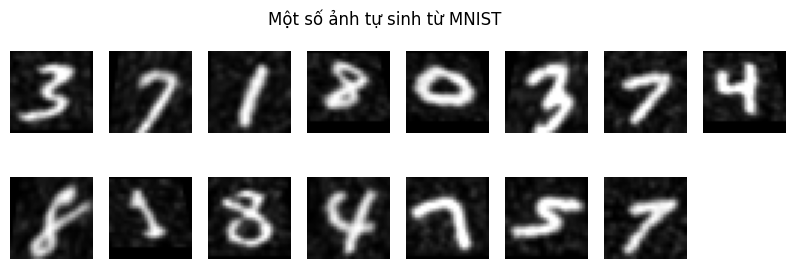

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
import glob
import cv2

# Load MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = np.expand_dims(x_train, axis=-1)
x_test  = np.expand_dims(x_test, axis=-1)

import random

def generate_random_image(img):
    """Sinh ảnh mới dựa trên 1 ảnh MNIST (augment mạnh)."""
    img = img.reshape(28, 28)

    # 1. Random rotation
    angle = random.randint(-25, 25)
    M = cv2.getRotationMatrix2D((14, 14), angle, 1)
    img_aug = cv2.warpAffine(img, M, (28, 28))

    # 2. Thêm nhiễu Gaussian
    noise = np.random.normal(0, 0.15, (28, 28))
    img_aug = np.clip(img_aug + noise, 0, 1)

    # 3. Làm mờ nhẹ
    img_aug = cv2.GaussianBlur(img_aug, (3, 3), 0)

    # 4. Biến dạng affine nhỏ
    pts1 = np.float32([[5,5], [22,5], [5,22]])
    shift = random.randint(-3,3)
    pts2 = np.float32([[5+shift,5],[22+shift,5],[5,22+shift]])
    M2 = cv2.getAffineTransform(pts1, pts2)
    img_aug = cv2.warpAffine(img_aug, M2, (28,28))

    # 5. Tăng/giảm độ sáng
    brightness = random.uniform(0.7, 1.3)
    img_aug = np.clip(img_aug * brightness, 0, 1)

    return img_aug.reshape(28,28,1)


# 🔥 Tự sinh 100 ảnh mới
num_new = 100
custom_images = []
custom_labels = []

for i in range(num_new):
    idx = random.randint(0, len(x_train)-1)
    base_img = x_train[idx]
    label = y_train[idx]

    new_img = generate_random_image(base_img)
    custom_images.append(new_img)
    custom_labels.append(label)

custom_images = np.array(custom_images)
custom_labels = np.array(custom_labels)


# Gộp vào MNIST
X = np.concatenate([x_train, custom_images], axis=0)
Y = np.concatenate([y_train, custom_labels], axis=0)

# One-hot
Y = to_categorical(Y, 10)

# CHIA TRAIN/TEST
from sklearn.model_selection import train_test_split
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", Y_train.shape)
print("y_val:", Y_val.shape)

plt.figure(figsize=(10,3))
for i in range(15):
    plt.subplot(2, 8, i+1)
    plt.imshow(custom_images[i].reshape(28,28), cmap='gray')
    plt.axis("off")
plt.suptitle("Một số ảnh tự sinh từ MNIST")
plt.show()


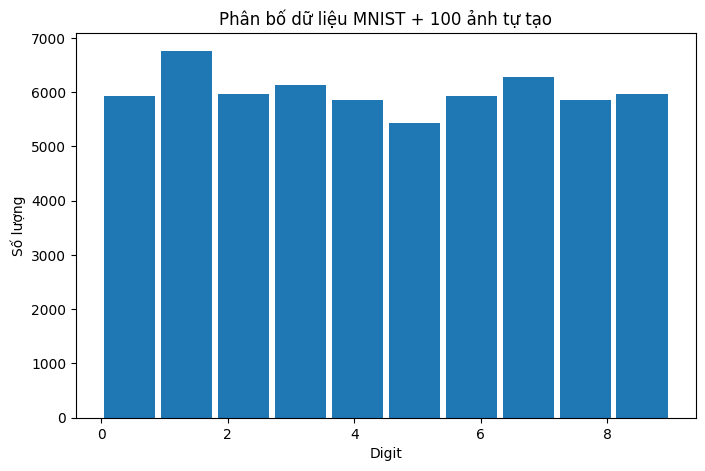

In [8]:
plt.figure(figsize=(8,5))
plt.hist(np.argmax(Y, axis=1), bins=10, rwidth=0.9)
plt.title("Phân bố dữ liệu MNIST + 100 ảnh tự tạo")
plt.xlabel("Digit")
plt.ylabel("Số lượng")
plt.show()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
752/752 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9311 - loss: 0.2225 - val_accuracy: 0.9781 - val_loss: 0.0687
Epoch 2/5
752/752 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.9756 - loss: 0.0798 - val_accuracy: 0.9856 - val_loss: 0.0480
Epoch 3/5
752/752 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9815 - loss: 0.0605 - val_accuracy: 0.9879 - val_loss: 0.0378
Epoch 4/5
752/752 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - accuracy: 0.9848 - loss: 0.0489 - val_accuracy: 0.9876 - val_loss: 0.0377
Epoch 5/5
752/752 ━━━━━━━━━━━━━━━━━━━━ 23s 26ms/step - accuracy: 0.9864 - loss: 0.0424 - val_accuracy: 0.9871 - val_loss: 0.0405
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9874 - loss: 0.0346
Độ chính xác mô hình Keras: 0.9873999953269958
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


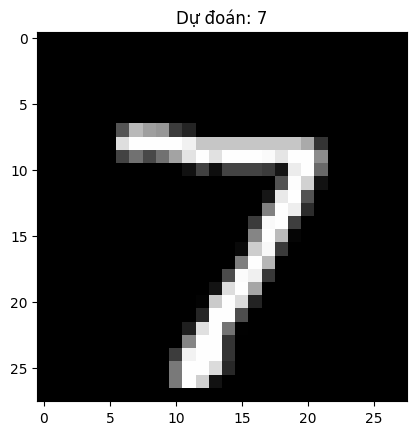

In [11]:
model_keras = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model_keras.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_keras.summary()

history = model_keras.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=5,
    batch_size=64
)

loss, acc = model_keras.evaluate(x_test, to_categorical(y_test, 10))
print("Độ chính xác mô hình Keras:", acc)

plt.imshow(x_test[0].reshape(28,28), cmap="gray")
plt.title("Dự đoán: " + str(np.argmax(model_keras.predict(x_test[0].reshape(1,28,28,1)))))
plt.show()
